In [2]:
import math
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
#1
print("Загрузка данных...")
df = pd.read_csv('SuperMarketAnalysis.csv')

df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Time'] = df['Time'].astype(str).str.split(':').str[0].astype(int)

columns_to_drop = [
    'Invoice ID', 'Quantity', 'Tax 5%', 'cogs',
    'gross margin percentage', 'gross income', 'Rating',
    'Date', 'Time'
]

Загрузка данных...


In [4]:
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df_clean = df.drop(columns=existing_columns_to_drop)

#2
target_col = 'Sales'
y = df_clean[target_col]
X = df_clean.drop(columns=[target_col])

numeric_features = X.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
categorical = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, numeric_features),
        ('cat', categorical, categorical_features)
    ])

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=10,
        random_state=42
    ))
])

In [5]:
# 3.Обучение и оценка
print("Обучение модели (Random Forest)...")
model_pipeline.fit(X_train, y_train)

y_train_pred = model_pipeline.predict(X_train)
y_test_pred = model_pipeline.predict(X_test)

mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

print("\nСравнение метрик: Обучение vs Тест")
print(f"Обучающая выборка (Train) -> R²: {r2_train:.3f} | MAE: {mae_train:.2f}| MSE: {mse_train:.2f} | RMSE: {rmse_train:.2f}")
print(f"Тестовая выборка  (Test)  -> R²: {r2_test:.3f} | MAE: {mae_test:.2f} | MSE: {mse_test:.2f}| RMSE: {rmse_test:.2f}")

Обучение модели (Random Forest)...

Сравнение метрик: Обучение vs Тест
Обучающая выборка (Train) -> R²: 0.507 | MAE: 133.59| MSE: 29195.45 | RMSE: 170.87
Тестовая выборка  (Test)  -> R²: 0.424 | MAE: 148.48 | MSE: 37441.71| RMSE: 193.50


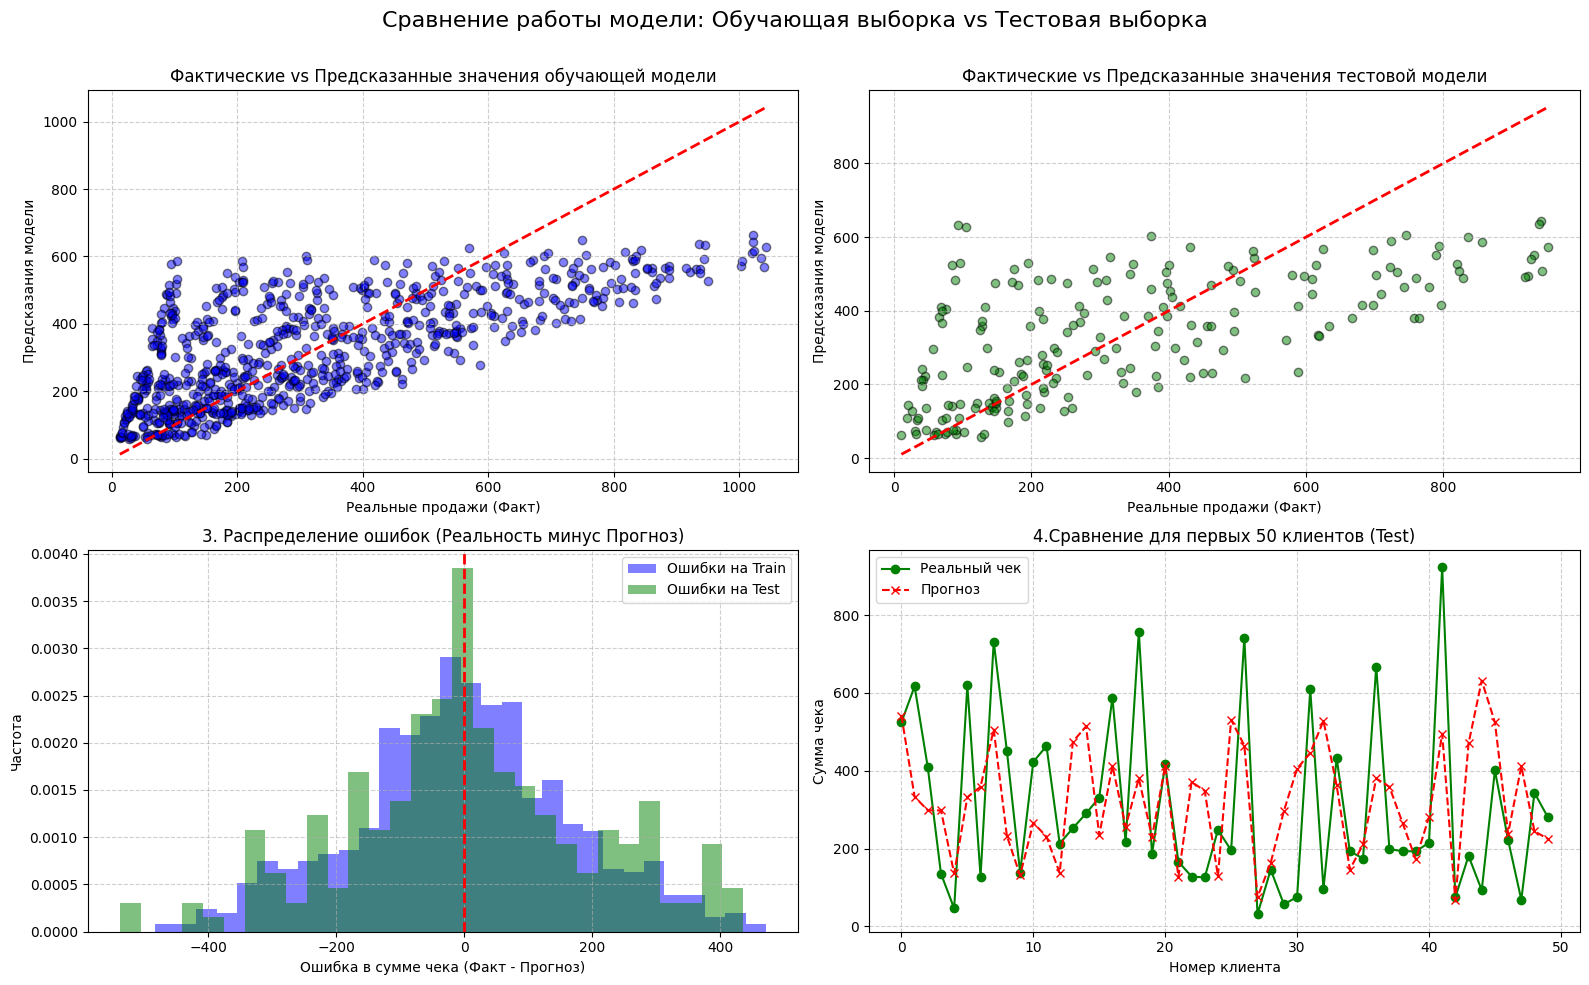


Топ-5 факторов, влияющих на итоговый чек (Sales)
                         Признак  Важность
                      Unit price  0.841283
                       DayOfWeek  0.043308
                     Gender_Male  0.014044
                   Gender_Female  0.013170
Product line_Fashion accessories  0.010825


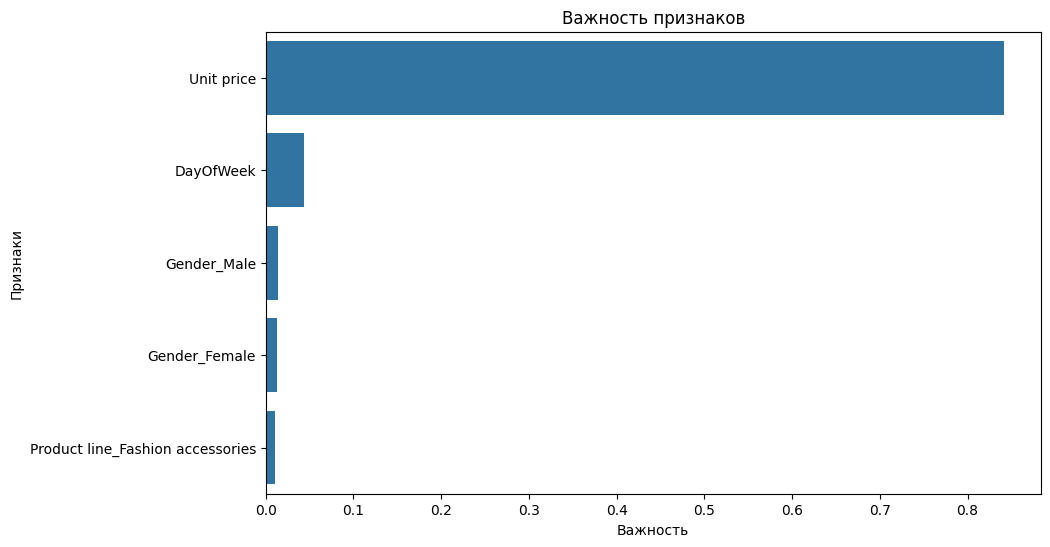

In [6]:
# 4.Визуализация
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Сравнение работы модели: Обучающая выборка vs Тестовая выборка', fontsize=16)

# График 1
axes[0, 0].scatter(y_train, y_train_pred, alpha=0.5, color='blue', edgecolor='k')
min_val_tr = min(y_train.min(), y_train_pred.min())
max_val_tr = max(y_train.max(), y_train_pred.max())
axes[0, 0].plot([min_val_tr, max_val_tr], [min_val_tr, max_val_tr], 'r--', lw=2)
axes[0, 0].set_title('Фактические vs Предсказанные значения обучающей модели')
axes[0, 0].set_xlabel('Реальные продажи (Факт)')
axes[0, 0].set_ylabel('Предсказания модели')
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# График 2
axes[0, 1].scatter(y_test, y_test_pred, alpha=0.5, color='green', edgecolor='k')
min_val_te = min(y_test.min(), y_test_pred.min())
max_val_te = max(y_test.max(), y_test_pred.max())
axes[0, 1].plot([min_val_te, max_val_te], [min_val_te, max_val_te], 'r--', lw=2)
axes[0, 1].set_title('Фактические vs Предсказанные значения тестовой модели')
axes[0, 1].set_xlabel('Реальные продажи (Факт)')
axes[0, 1].set_ylabel('Предсказания модели')
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# График 3: Распределение ошибок
error_train = y_train - y_train_pred
error_test = y_test - y_test_pred

axes[1, 0].hist(error_train, bins=30, alpha=0.5, color='blue', label='Ошибки на Train', density=True)
axes[1, 0].hist(error_test, bins=30, alpha=0.5, color='green', label='Ошибки на Test', density=True)
axes[1, 0].set_title('3. Распределение ошибок (Реальность минус Прогноз)')
axes[1, 0].set_xlabel('Ошибка в сумме чека (Факт - Прогноз)')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].axvline(0, color='red', linestyle='--', lw=2) # Линия идеального нуля
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# График 4 Сравнение
num_samples = 50
axes[1, 1].plot(np.arange(num_samples), y_test.values[:num_samples], marker='o', label='Реальный чек', color='green')
axes[1, 1].plot(np.arange(num_samples), y_test_pred[:num_samples], marker='x', linestyle='--', label='Прогноз', color='red')
axes[1, 1].set_title(f'4.Cравнение для первых {num_samples} клиентов (Test)')
axes[1, 1].set_xlabel('Номер клиента')
axes[1, 1].set_ylabel('Сумма чека')
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# 5. Важность признаков
model = model_pipeline.named_steps['regressor']
encoded_cat_cols = model_pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features)
all_features = numeric_features + list(encoded_cat_cols)

importances = model.feature_importances_
feature_imp_df = pd.DataFrame({'Признак': all_features, 'Важность': importances})
feature_imp_df = feature_imp_df.sort_values(by='Важность', ascending=False).head(5)

print("\nТоп-5 факторов, влияющих на итоговый чек (Sales)")
print(feature_imp_df.to_string(index=False))


plt.figure(figsize=(10,6))
sns.barplot(x='Важность', y='Признак', data=feature_imp_df)
plt.title('Важность признаков')
plt.xlabel('Важность')
plt.ylabel('Признаки')
plt.show()